## Setup and Installation

In [1]:
!pip install gensim nltk matplotlib scikit-learn numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.7 MB/s eta 0:00:00:00:010:01m


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import nltk
from nltk.corpus import brown

nltk.download('brown', quiet=True)
nltk.download('punkt', quiet=True)

True

## Part 1: Training Word2Vec from Scratch

We'll train a Word2Vec model on the Brown corpus (a small but diverse text corpus).

In [3]:
# Load Brown corpus
sentences = brown.sents()[:10000]  # Use first 10k sentences for faster training
print(f"Number of sentences: {len(sentences)}")
print(f"Sample sentence: {sentences[0]}")

Number of sentences: 10000
Sample sentence: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [4]:
# Train Word2Vec model
# vector_size: dimensionality of word vectors
# window: context window size
# min_count: ignore words with frequency lower than this
# sg: 0 for CBOW, 1 for Skip-gram

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,  # Skip-gram
    epochs=10
)

print(f"Vocabulary size: {len(model.wv)}")

Vocabulary size: 4839


### Exploring Word2Vec Results

In [5]:
# Find similar words
test_words = ['king', 'woman', 'computer', 'good', 'city']

for word in test_words:
    if word in model.wv:
        print(f"\nWords similar to '{word}':")
        similar = model.wv.most_similar(word, topn=5)
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.3f}")
    else:
        print(f"\n'{word}' not in vocabulary")


'king' not in vocabulary

Words similar to 'woman':
  baby: 0.901
  memory: 0.894
  lawyer: 0.891
  ring: 0.879
  gas: 0.879

'computer' not in vocabulary

Words similar to 'good':
  bad: 0.840
  fine: 0.802
  usually: 0.801
  quite: 0.798
  piece: 0.795

Words similar to 'city':
  increasing: 0.845
  acceptance: 0.831
  CD: 0.819
  confronting: 0.819
  agencies: 0.816


In [ ]:

analogy = {
    "description": "he - man + woman ≈ she",
    "positive": ["woman", "he"],
    "negative": ["man"],
}

missing = [w for w in analogy["positive"] + analogy["negative"] if w not in model.wv]
if missing:
    print(f"Skipping analogy; missing words in vocabulary: {missing}")
else:
    try:
        result = model.wv.most_similar(positive=analogy["positive"], negative=analogy["negative"], topn=5)
        print(f"\nWord Analogy: {analogy['description']}")
        for word, score in result:
            print(f"  {word}: {score:.3f}")
    except KeyError as e:
        print(f"Vocabulary lookup error: {e}")


Word Analogy: he - man + woman ≈ she
  1956: 0.744
  after: 0.741
  started: 0.737
  stopped: 0.736
  Player: 0.735


## Part 2: Using Pre-trained GloVe Embeddings

In [8]:
# Download GloVe embeddings (small version)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
!ls -lh glove.6B.*.txt

-rw-rw-r-- 1 root root 332M Aug  4  2014 glove.6B.100d.txt
-rw-rw-r-- 1 root root 662M Aug  4  2014 glove.6B.200d.txt
-rw-rw-r-- 1 root root 990M Aug 27  2014 glove.6B.300d.txt
-rw-rw-r-- 1 root root 164M Aug  4  2014 glove.6B.50d.txt


In [9]:
# Load GloVe vectors (50d version for speed)
def load_glove_embeddings(file_path, limit=50000):
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            if idx >= limit:
                break
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove = load_glove_embeddings('glove.6B.50d.txt')
print(f"Loaded {len(glove)} word vectors")
print(f"Vector dimension: {len(glove['hello'])}")

Loaded 50000 word vectors
Vector dimension: 50


In [10]:
# Find similar words using cosine similarity
from numpy.linalg import norm

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

def find_similar_glove(word, embeddings, topn=5):
    if word not in embeddings:
        return f"'{word}' not in vocabulary"
    
    word_vec = embeddings[word]
    similarities = {}
    
    for other_word, other_vec in embeddings.items():
        if other_word != word:
            sim = cosine_similarity(word_vec, other_vec)
            similarities[other_word] = sim
    
    return sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:topn]

# Test with some words
test_words = ['king', 'computer', 'happy', 'city']
for word in test_words:
    print(f"\nWords similar to '{word}':")
    similar = find_similar_glove(word, glove, topn=5)
    for sim_word, score in similar:
        print(f"  {sim_word}: {score:.3f}")


Words similar to 'king':
  prince: 0.824
  queen: 0.784
  ii: 0.775
  emperor: 0.774
  son: 0.767

Words similar to 'computer':
  computers: 0.917
  software: 0.881
  technology: 0.853
  electronic: 0.813
  internet: 0.806

Words similar to 'happy':
  'm: 0.914
  everyone: 0.898
  everybody: 0.897
  really: 0.884
  me: 0.878

Words similar to 'city':
  town: 0.869
  downtown: 0.853
  where: 0.853
  cities: 0.850
  area: 0.832


## Part 3: Visualizing Embeddings with t-SNE

We'll visualize word embeddings in 2D space using t-SNE dimensionality reduction.

In [11]:
# Select interesting words to visualize
words_to_plot = [
    # Countries
    'france', 'germany', 'italy', 'spain', 'china', 'japan', 'india',
    # Cities
    'paris', 'london', 'rome', 'beijing', 'tokyo', 'delhi',
    # Animals
    'dog', 'cat', 'lion', 'tiger', 'elephant',
    # Food
    'pizza', 'burger', 'sushi', 'curry',
    # Technology
    'computer', 'phone', 'internet', 'software',
    # Emotions
    'happy', 'sad', 'angry', 'excited'
]

# Filter words that exist in GloVe
words_to_plot = [w for w in words_to_plot if w in glove]
print(f"Visualizing {len(words_to_plot)} words")

Visualizing 30 words


In [12]:
# Get embeddings for selected words
word_vectors = np.array([glove[word] for word in words_to_plot])

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=15, n_iter=1000)
embeddings_2d = tsne.fit_transform(word_vectors)

print(f"Reduced {word_vectors.shape[1]}D embeddings to 2D")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Reduced 50D embeddings to 2D


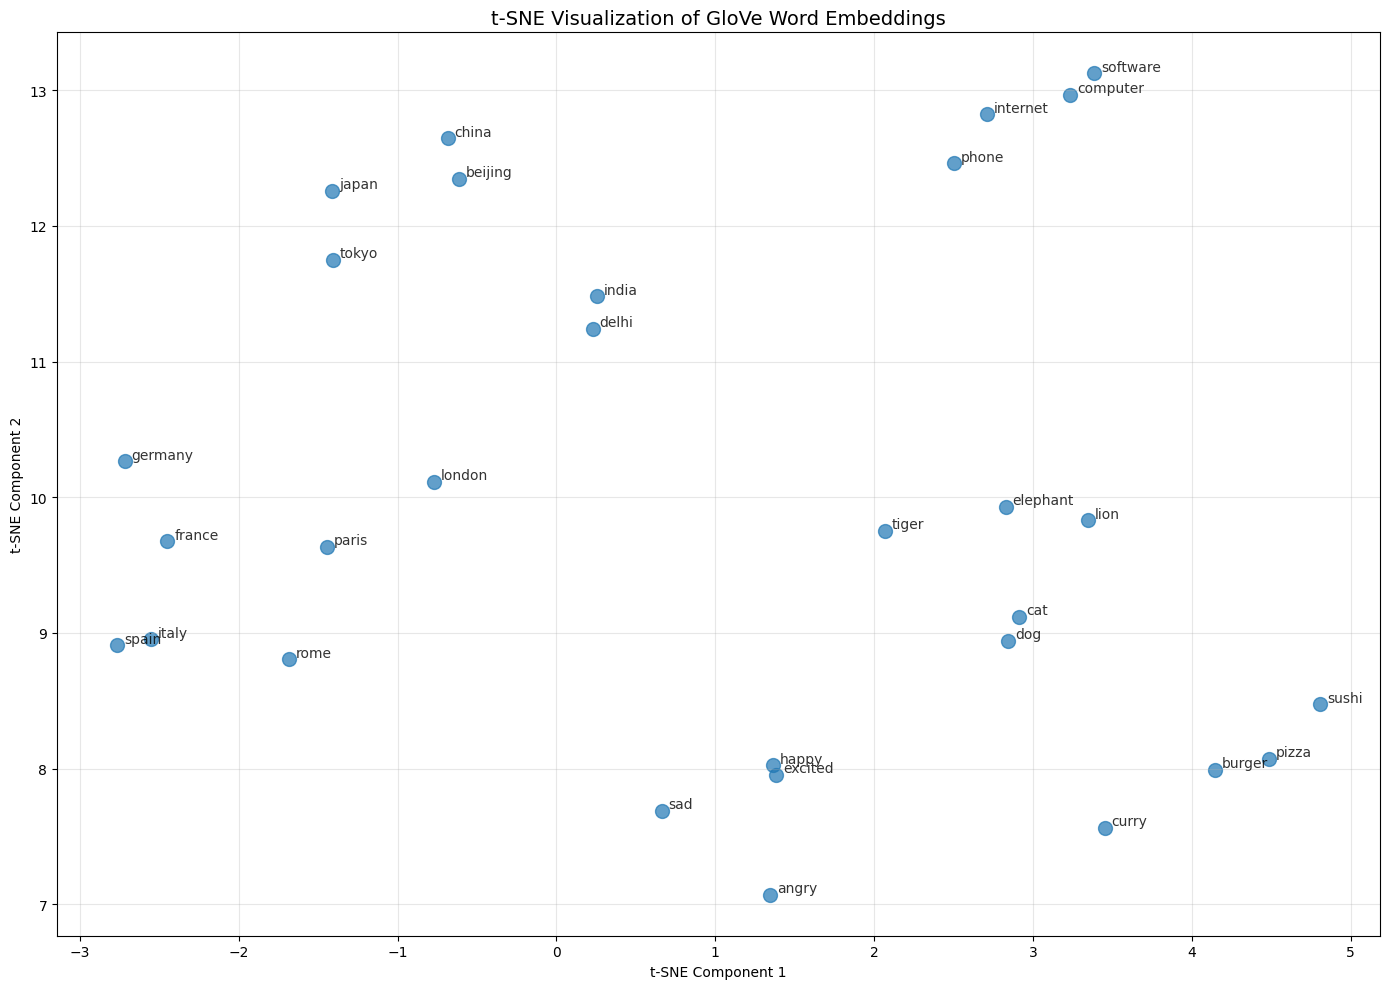

In [13]:
# Plot the embeddings
plt.figure(figsize=(14, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=100)

# Annotate points
for i, word in enumerate(words_to_plot):
    plt.annotate(word, 
                xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                xytext=(5, 2),
                textcoords='offset points',
                fontsize=10,
                alpha=0.8)

plt.title('t-SNE Visualization of GloVe Word Embeddings', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 4: Comparing PCA vs t-SNE

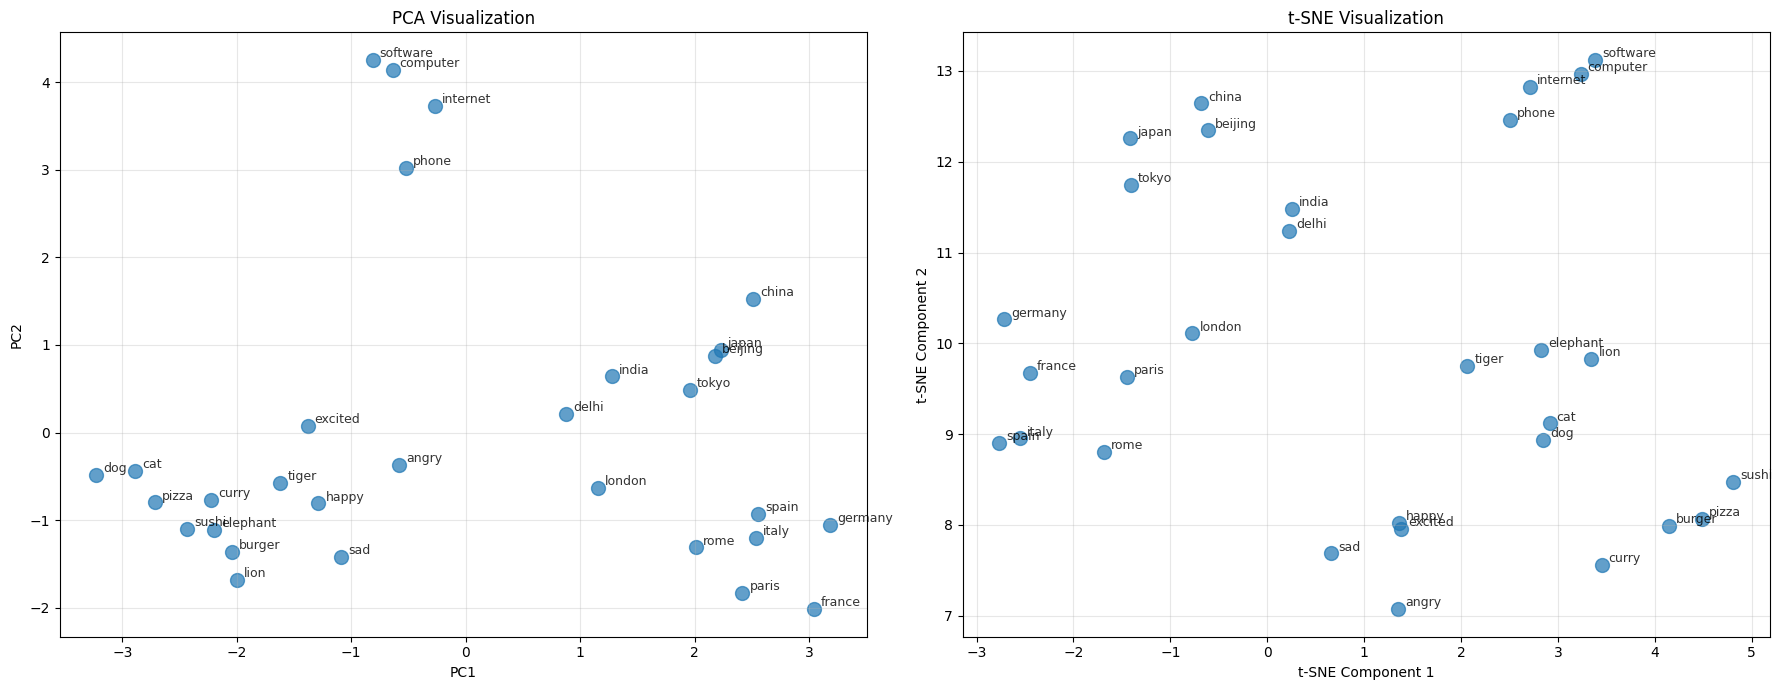


Observations:
- PCA preserves global structure (linear relationships)
- t-SNE preserves local structure (neighborhood relationships)
- t-SNE often creates better visual clusters for similar words


In [14]:
# Apply PCA
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(word_vectors)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA plot
axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.7, s=100)
for i, word in enumerate(words_to_plot):
    axes[0].annotate(word, 
                    xy=(embeddings_pca[i, 0], embeddings_pca[i, 1]),
                    xytext=(5, 2),
                    textcoords='offset points',
                    fontsize=9,
                    alpha=0.8)
axes[0].set_title('PCA Visualization', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# t-SNE plot
axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=100)
for i, word in enumerate(words_to_plot):
    axes[1].annotate(word, 
                    xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    xytext=(5, 2),
                    textcoords='offset points',
                    fontsize=9,
                    alpha=0.8)
axes[1].set_title('t-SNE Visualization', fontsize=12)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- PCA preserves global structure (linear relationships)")
print("- t-SNE preserves local structure (neighborhood relationships)")
print("- t-SNE often creates better visual clusters for similar words")

## Key Takeaways

1. **Word2Vec**: Trains word embeddings from scratch using either CBOW or Skip-gram
2. **GloVe**: Pre-trained embeddings based on global word co-occurrence statistics
3. **t-SNE**: Better for visualizing local neighborhoods in high-dimensional data
4. **PCA**: Better for understanding global variance and linear relationships
5. Similar words cluster together in the embedding space